# Agent Based Models Review/Practice

> Computational Analysis of Social Complexity

**Prerequisites**

- ABM
- Shelling segregation model

**Outcomes**

- Recall key components of ABM
- Review additional example of ABM in Python


**References**

- https://proceedings.scipy.org/articles/Majora-7b98e3ed-009.pdf
- https://mesa.readthedocs.io/
- https://mesa.readthedocs.io/stable/tutorials/intro_tutorial.html

## Agent Based Models

- Agent based models are...
    - An approximation to some complex system (a model)
    - Used in various fields including biology, epidemiology, economics, etc.
    - Composed of three key elements: (1) Agents (2) Environment (3) Rules

## Schelling Segregation Model

- Recall the Schelling segregation model...
- Agents: individuals/families seeking a home in a neighborhood. Have a type and hapiness. Agents are happy if least $N$ of their neighbors are same type
- Environment: grid of "lots" or homes where agents can live
- Rules: All unhappy agents move to a new random home in the environment

### Schelling Takeaways

- Very simplistic view of agents (people) and decision making criterion (rules)
- Agents only considered immediate neighbors when deciding to move (locality)
- Simplistic, local behavior led to stark aggregate results: segregation of neighborhoods into agent types
- mesa implementation very straightforward: `class` (subclassing `mesa.Agent`) to represent an agent, `class` (subclassing `mesa.Model`, mesa-defined) to represent the environment, `method` to represent rules for a single agent

## Plan today

- See example of second model
- Break into groups and study example models from the [mesa examples repository](https://github.com/projectmesa/mesa-examples)
    - Present model your group studied

## Money Model

- Agents:
    - $N$ Agents
    - All start with 1.0 wealth
- Environment: none -- they just exist ;)
- Rules:
    - If agent has at least 1.0 wealth, gives 1.0 wealth to another agent
    - If agent has 0 wealth, does nothing

### Agents

In [1]:
# Dependencies (numpy, pandas, mesa, matplotlib) are already installed via uv;
# see pyproject.toml. No package installation step is needed here.

In [2]:
import numpy as np
import pandas as pd
import mesa


class MoneyAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.wealth = 1

    def step(self):
        money_agent_step(self)

### Rules

In [3]:
def money_agent_step(agent):
    if agent.wealth == 0:
        return
    recipient = agent.model.random.choice(list(agent.model.agents))
    agent.wealth -= 1
    recipient.wealth += 1

### Model

In [4]:
class MoneyModel(mesa.Model):
    def __init__(self, N=100, rng=None):
        super().__init__(rng=rng)
        for _ in range(N):
            MoneyAgent(self)
        self.datacollector = mesa.DataCollector(agent_reporters={"wealth": "wealth"})
        self.datacollector.collect(self)

    def step(self):
        self.agents.do("step")
        self.datacollector.collect(self)


MoneyModel()

### Simulation

In [5]:
m = MoneyModel(N=2000, rng=6318)
for _ in range(10):
    m.step()

df = m.datacollector.get_agent_vars_dataframe()

In [6]:
import matplotlib.pyplot as plt

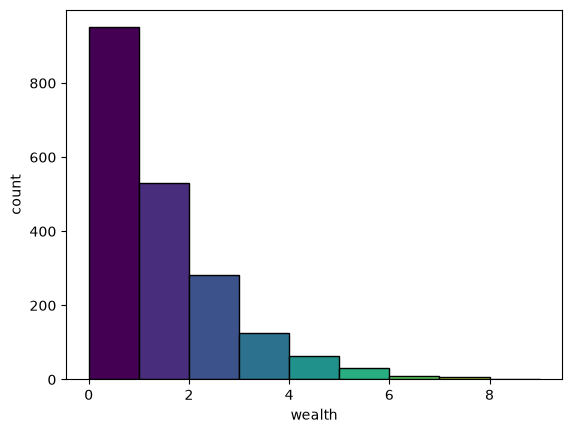

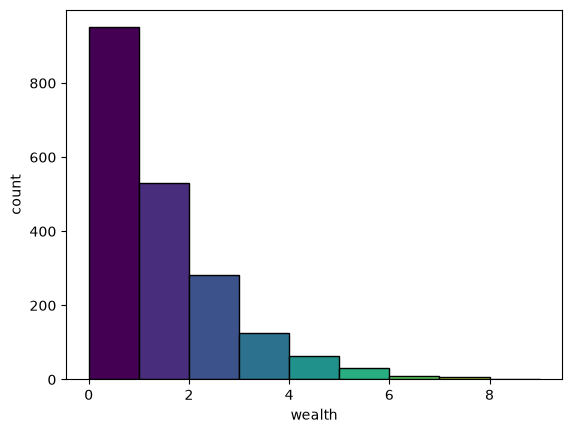

In [7]:
final_wealth = df.xs(10, level="Step")["wealth"]
counts, bin_edges = np.histogram(final_wealth, bins=range(0, 10))
cmap = plt.get_cmap("viridis")
colors = [cmap(i / (len(counts) - 1)) for i in range(len(counts))]

fig, ax = plt.subplots()
ax.bar(bin_edges[:-1], counts, width=1, align="edge", color=colors, edgecolor="black")
ax.set_xlabel("wealth")
ax.set_ylabel("count")
fig

- What do we see? With 2000 agents starting with equal wealth (1 unit each), after just 10 steps most agents have 0 or 1 units of wealth while very few have accumulated 5+ units
- This concentration of wealth in the hands of a few emerges naturally from random exchanges!
- Above we see the famous "power law" pattern
- This is a common result in many areas of economics: that activity or wealth is concentrated in the very few (the 1%) 
    - References: https://pubs.aeaweb.org/doi/pdf/10.1257/jep.30.1.185, https://www.sciencedirect.com/science/article/abs/pii/S0378437197002173, https://www.theguardian.com/commentisfree/2011/nov/11/occupy-movement-wealth-power-law-distribution

### Exercise: Effect of Population Size

Try running the simulation with different population sizes to see how the wealth distribution changes:
- Run with `N=100`, `N=500`, and `N=5000`
- Compare the histograms - does the power law pattern persist?
- How many steps does it take for the pattern to emerge with different N?

## Money Model with space

- Let's expand our environment to a 2d-grid and only allow sharing wealth amongst neighbors
- Changes relative to previous setup:
    - Agents now have a position
    - Environment is a 2d grid (`mesa.space.MultiGrid`)
    - Agents randomly pick a neighbor to give money to

In [8]:
class WealthInSpace(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.wealth = 1

    def step(self):
        wealth_in_space_step(self)

In [9]:
def wealth_in_space_step(agent):
    if agent.wealth == 0:
        return

    neighbors = agent.model.grid.get_neighbors(agent.pos, moore=True, include_center=False)
    if not neighbors:
        return

    recipient = agent.model.random.choice(neighbors)
    agent.wealth -= 1
    recipient.wealth += 1

In [10]:
import itertools


class MoneyModel2D(mesa.Model):
    def __init__(self, dims=(25, 25), rng=None):
        super().__init__(rng=rng)
        width, height = dims
        # periodic=True (torus=True) means agents at edges can interact with agents on
        # the opposite edge. This creates a torus topology - think of it like Pac-Man
        # where going off one side brings you to the other side.
        self.grid = mesa.space.MultiGrid(width, height, torus=True)

        for pos in itertools.product(range(width), range(height)):
            agent = WealthInSpace(self)
            self.grid.place_agent(agent, pos)

        self.datacollector = mesa.DataCollector(agent_reporters={"wealth": "wealth", "pos": "pos"})
        self.datacollector.collect(self)

    def step(self):
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

In [11]:
m2d = MoneyModel2D(rng=6318)
for _ in range(10):
    m2d.step()

df2d = m2d.datacollector.get_agent_vars_dataframe()

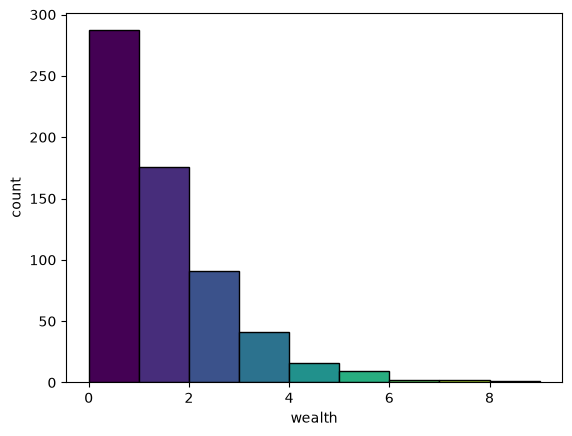

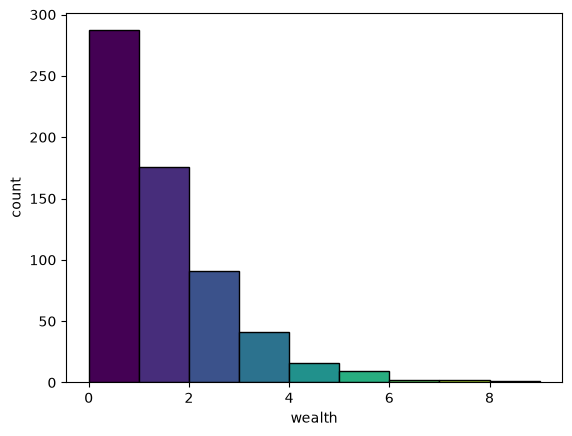

In [12]:
final_wealth_2d = df2d.xs(10, level="Step")["wealth"]
counts, bin_edges = np.histogram(final_wealth_2d, bins=range(0, 10))
cmap = plt.get_cmap("viridis")
colors = [cmap(i / (len(counts) - 1)) for i in range(len(counts))]

fig, ax = plt.subplots()
ax.bar(bin_edges[:-1], counts, width=1, align="edge", color=colors, edgecolor="black")
ax.set_xlabel("wealth")
ax.set_ylabel("count")
fig

- Still a power law... very pervasive!

In [13]:
def make_heatmap(model, df, T=None):
    if T is None:
        T = df.index.get_level_values("Step").max()
    df_T = df.xs(T, level="Step")

    width, height = model.grid.width, model.grid.height
    arr = np.zeros((width, height))
    for pos, wealth in zip(df_T["pos"], df_T["wealth"]):
        arr[pos] += wealth

    fig, ax = plt.subplots(figsize=(6, 4.5))
    im = ax.imshow(arr.T, origin="lower", cmap="viridis")
    ax.set_title(f"T = {T}")
    fig.colorbar(im, ax=ax)
    return fig

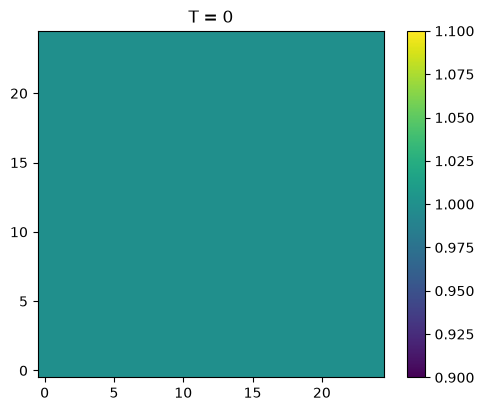

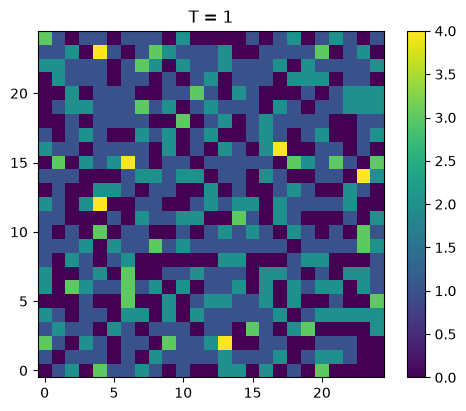

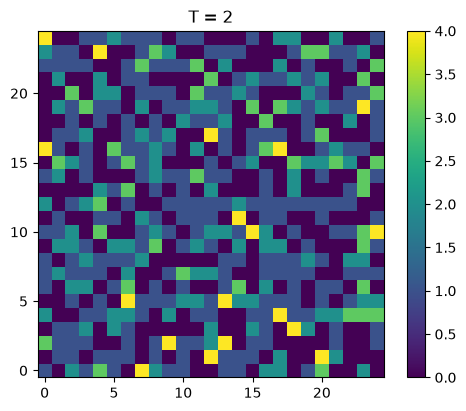

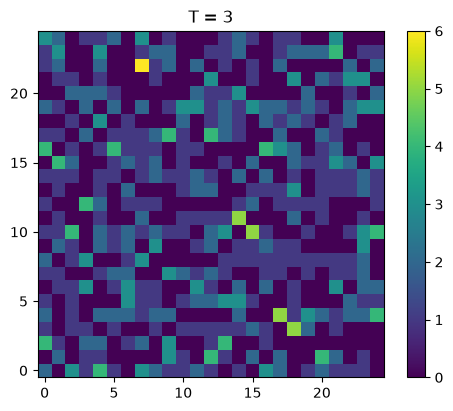

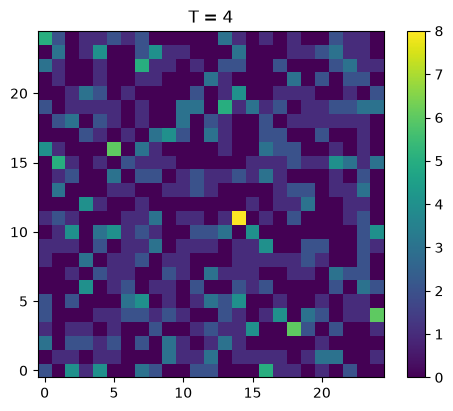

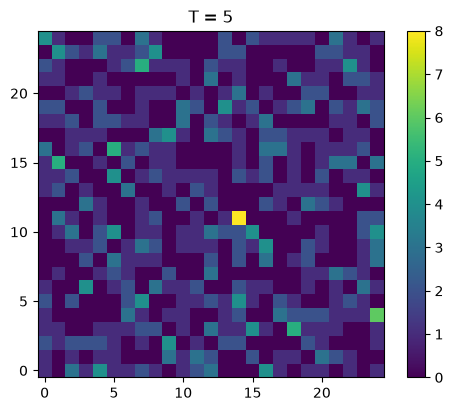

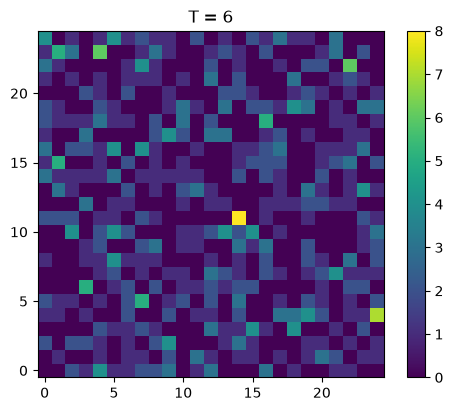

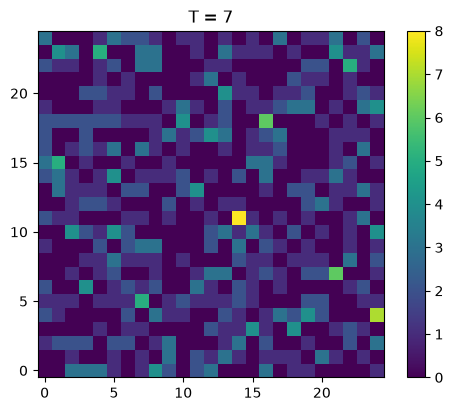

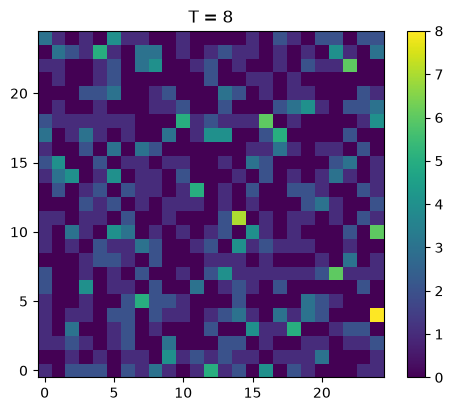

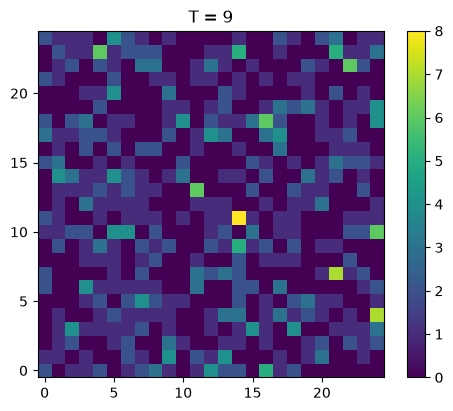

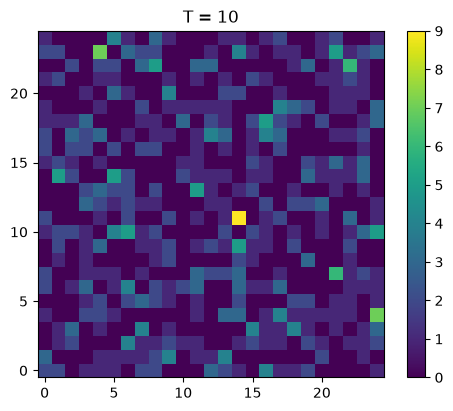

In [14]:
for t in range(11):
    make_heatmap(m2d, df2d, t)
    plt.show()